<a href="https://colab.research.google.com/github/mooch443/dataset-fixer/blob/main/notebooks/02_task_aware_tiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Task-aware image tiling

This tutorial demonstrates `Dataset.tile()` with overlapping, edge-aligned crops and two negative-tile policies. The package applies equivalent task-aware geometry rules to detection, segmentation, pose, and POLO data.

> **AI-generation disclosure:** this project and tutorial are largely AI-generated under human direction and review. Independently validate results for your data.

The example uses official images and YOLO labels from the public [SAWIT dataset](https://github.com/dtnguyen0304/sawit), which declares the [MIT License](https://github.com/dtnguyen0304/sawit/blob/main/LICENSE).

## 1. Install into the active notebook kernel

In [1]:
from pathlib import Path
import nnunetv2

CUSTOM_TRAINER_FILE = (
    Path(nnunetv2.__file__).parent
    / "training"
    / "nnUNetTrainer"
    / "variants"
    / "training_length"
    / "nnUNetTrainer_184epochs.py"
)

CUSTOM_TRAINER_FILE.write_text(
    """
import torch

from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer


class nnUNetTrainer_184epochs(nnUNetTrainer):
    def __init__(
        self,
        plans: dict,
        configuration: str,
        fold: int,
        dataset_json: dict,
        device: torch.device = torch.device("cuda"),
    ):
        super().__init__(
            plans,
            configuration,
            fold,
            dataset_json,
            device,
        )
        self.num_epochs = 184
""".lstrip()
)

print(f"Created: {CUSTOM_TRAINER_FILE}")

Created: /Users/tristan/miniforge3/envs/jupyter/lib/python3.11/site-packages/nnunetv2/training/nnUNetTrainer/variants/training_length/nnUNetTrainer_184epochs.py


In [1]:
from dataset_fixer import Dataset

masks = Dataset.open(
    #"/Users/tristan/Downloads/island-dataset/islands-base",
    "/Users/tristan/Downloads/island-dataset/islands-fair-base-sem",
    #"/Users/tristan/Downloads/island-dataset/islands-128-07.08.2026_masks",
    #"/Users/tristan/Downloads/island-dataset/islands-128-no-black-large"
    #"/Users/tristan/Downloads/island-dataset/islands-128-no-black"
)


Loading semantic-mask dataset:   0%|          | 0/4692 [00:00<?, ?pair/s]

Validating dataset:   0%|          | 0/4692 [00:00<?, ?image/s]

In [4]:
from dataset_fixer import Model, ModelCollection

sahi = {
    "inference": "sahi",
    "sahi_slice_height": 128,
    "sahi_slice_width": 128,
    "sahi_overlap": 0.15,
    "device":"mps",
    "workers": 4,
}
#sahi = {
#    "device":"mps",
#    "workers": 4,
#}

models : ModelCollection = Model.load_many({
    "128-08.08.2026-merged-1class_masks_yolo26m-sem": {
        "path": '/Users/tristan/Downloads/yolo26m-sem-545140752920/weights/best.pt',
        "upscale_factor": 2,
        "task": "semantic",
        **sahi,
    },
    "1class_yolo-yolox": {
        "path":"/Users/tristan/Downloads/islands-128-08.08.2026-merged-1class_yolo-128px-yolox.pt",
        "upscale_factor": 2,
        "task": "semantic",
        **sahi,
    }
})


In [5]:
#masks.export(destination="/Users/tristan/Downloads/island-dataset/islands-base-sem", format="semantic_masks")

In [ ]:
from dataset_fixer import Model, ModelCollection

sahi = {
    "inference": "sahi",
    "sahi_slice_height": 128,
    "sahi_slice_width": 128,
    "sahi_overlap": 0.15,
    "device":"mps",
    "workers": 4,
}
#sahi = {
#    "device":"mps",
#    "workers": 4,
#}

models : ModelCollection = Model.load_many(
    {
        #"model-b": {
        #    "model_folder": "/Users/tristan/Downloads/nnUNet_results_islands-128-no-black/Dataset967_IslandTiles128u2_742ef717/nnUNetTrainer_100epochs__nnUNetResEncUNetPlans__2d",
        #    "upscale_factor": 2,
        #    "checkpoint": "checkpoint_best.pth",
        #},
        #"more-upscale": {
        #    "model_folder": "/Users/tristan/Downloads/Dataset802_IslandTiles128u4_44389e96/nnUNetTrainer_100epochs__nnUNetResEncUNetPlans__2d",
        #    "upscale_factor": 4,
        #    "checkpoint": "checkpoint_best.pth",
        # },
        "resenc_m-emoDice0.5684-02.08.2026-2109": {
            "path": "/Users/tristan/Downloads/nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__2d",
            "upscale_factor": 4,
            "checkpoint": "checkpoint_best.pth",
            **sahi,
        },
        "resenc_m-best-meanFgDice0.5964-step059-epoch060-02.08.2026-2137": {
            "path": "/Users/tristan/Downloads/nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__2d 2",
            "upscale_factor": 2,
            "checkpoint": "checkpoint_best_mean_fg_dice.pth",
            **sahi,
        },
        "8aafo0mh-best-fg": {
            "path": "/Users/tristan/Downloads/nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__2d 3",
            "upscale_factor": 2,
            "checkpoint": "checkpoint_best_mean_fg_dice.pth",
            **sahi,
        },
        "angela_yolo": {
            "path":"/Users/tristan/Downloads/island-dataset/best.pt",
            "task": "segment",
            "resolution": 256,
            **sahi,
        },
        "20260806-full-2classes": {
            "path":"/Users/tristan/Downloads/20260806-full-2classes-tiled-best.pt",
            "task": "segment",
            "resolution": 256,
            **sahi,
        },
        "bl3whwev": {
            "path":"/Users/tristan/Downloads/yolo26m-sem-a44b74fd0a20/weights/best.pt",
            "task": "semantic",
            "resolution": 256,
            **sahi,
        }
    },
)


In [5]:
from dataset_fixer import Model, ModelCollection

sahi = {
    "inference": "sahi",
    "sahi_slice_height": 128,
    "sahi_slice_width": 128,
    "sahi_overlap": 0.15,
    "device":"mps",
    "workers": 4,
}
#sahi = {
#    "device":"mps",
#    "workers": 4,
#}

models : ModelCollection = Model.load_many({
    "xb4krq8b": {
        "path": '/Users/tristan/Downloads/nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__2d 4',
        "upscale_factor": 2,
        "checkpoint": "checkpoint_best_mean_fg_dice.pth",
        **sahi,
    },
    "yolo26m-sem-e60e5fcf4024": {
        "path":"/Users/tristan/Downloads/yolo26m-sem-e60e5fcf4024/weights/best.pt",
        "task": "semantic",
        "resolution": 256,
        **sahi,
    },
    "nnunet-74to28yw": {
        "path":'/Users/tristan/Downloads/nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__2d 5',
        "task": "semantic",
        "checkpoint": "checkpoint_best_mean_fg_dice.pth",
        "resolution": 256,
        **sahi,
    },
    "bl3whwev": {
        "path":"/Users/tristan/Downloads/yolo26m-sem-a44b74fd0a20/weights/best.pt",
        "task": "semantic",
        "resolution": 256,
        **sahi,
    },
    "resenc_m-best-meanFgDice0.5964-step059-epoch060-02.08.2026-2137": {
        "path": "/Users/tristan/Downloads/nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__2d 2",
        "upscale_factor": 2,
        "checkpoint": "checkpoint_best_mean_fg_dice.pth",
        **sahi,
    },
    "8aafo0mh-best-fg": {
        "path": "/Users/tristan/Downloads/nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__2d 3",
        "upscale_factor": 2,
        "checkpoint": "checkpoint_best_mean_fg_dice.pth",
        **sahi,
    },
    "20260806-full-2classes": {
        "path":"/Users/tristan/Downloads/20260806-full-2classes-tiled-best.pt",
        "task": "segment",
        "resolution": 256,
        **sahi,
    },
})


In [6]:
comparison = models.compare(
    masks,
    split="val",
    save_prediction_plots=True,
    #baseline="angela_yolo",
)

1class_yolo-yolox SAHI 0.7:   0%|          | 0/1205 [00:00<?, ?it/s]

DatasetValidationError: Dataset validation failed with 1 error(s):
  1. 1class_yolo-yolox:000a3827-88010369-ecf5-4264-8b0b-1d0234e59103_20220209_052853_37_2406_3B_Analyt_MvwLvXI.png:tile-0: Semantic model result has no semantic_mask; expected an Ultralytics task='semantic' result

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

figure = models.visualize(
    source=masks,
    split="val",
    samples=16,
    examples_per_row=1,
    panel_size=4,
    destination="quick-comparison.png",
)



In [ ]:

comparison = models.compare(
    source=masks,
    split="val",
    baseline="resenc_m-emoDice0.5684-02.08.2026-2109",
)

comparison.ranking
comparison.location

In [ ]:
%pip install -q "git+https://github.com/mooch443/dataset-fixer.git"

In [1]:
import tempfile
from pathlib import Path

import dataset_fixer
print('dataset-fixer:', dataset_fixer.__version__, dataset_fixer.__file__)
WORK_ROOT = Path('/Users/tristan/Downloads/island-dataset')#Path('/content') if Path('/content').is_dir() else Path(tempfile.gettempdir()) / 'dataset-fixer-notebooks'
WORK_ROOT.mkdir(parents=True, exist_ok=True)
WORK_ROOT

dataset-fixer: 0.1.1.dev10+gafb37083e.d20260731 /Users/tristan/Documents/dataset-fixer/src/dataset_fixer/__init__.py


PosixPath('/Users/tristan/Downloads/island-dataset')

In [2]:
import re
from pathlib import Path

AOI_PATTERN = re.compile(
    r"(?i)([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-"
    r"[0-9a-f]{4}-[0-9a-f]{12})_20\d{6}(?:_|$)"
)

def get_aoi(filename: str | Path) -> str:
    name = Path(filename).name
    match = AOI_PATTERN.search(name)

    if match is None:
        raise ValueError(f"Could not extract AOI UUID from {name!r}")

    return match.group(1).lower()

## 2. Download the pinned public dataset subset

The downloader retains upstream pixels, filenames, and YOLO labels exactly. It writes the pinned commit, upstream MIT license, and SHA-256 values to `SOURCE.json`.

Loading YOLO dataset:   0%|          | 0/4692 [00:00<?, ?image/s]

Validating dataset:   0%|          | 0/4692 [00:00<?, ?image/s]

Validation skip audit: 1 failed item(s); showing 1 example(s) (maximum 4).


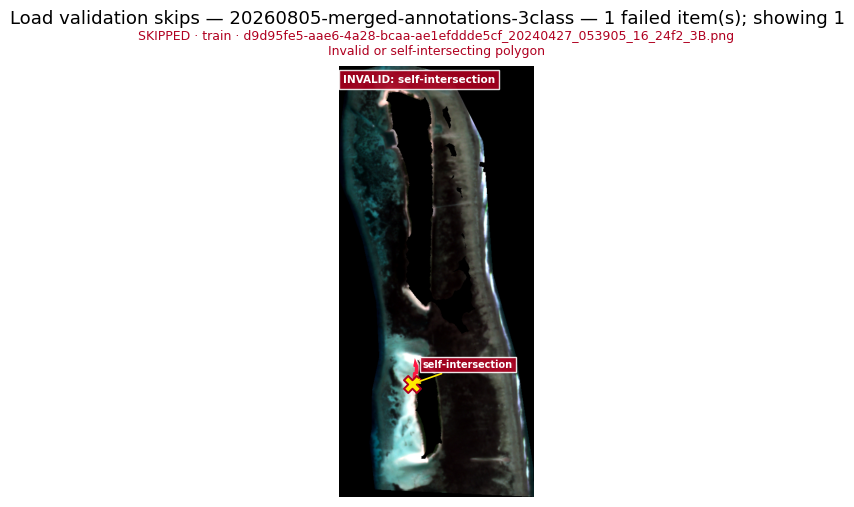

Dataset '20260805-merged-annotations-3class' [segment; materialized; yolo]
  images: 4692 | annotations: 1037 | empty: 4234 (90.2%)
  classes: 3 | splits: 1
  image sizes: 177 unique | width 69-4733 | height 65-2841
  location: /Users/tristan/Downloads/island-dataset/20260805-merged-annotations-3class

  Split statistics
    split  images  annotated  empty  annotations
    -----  ------  ---------  -----  -----------
    train    4692        458   4234         1037
    total    4692        458   4234         1037

  Class statistics (annotation instances and images containing class)
    id  name    annotations  images  image %
    --  ------  -----------  ------  -------
     0  Fish_1          830     403     8.6%
     1  Fish_2          139      86     1.8%
     2  Fish_3           68      47     1.0%
  data_yaml: /Users/tristan/Downloads/island-dataset/20260805-merged-annotations-3class/data.yaml
  validation: passed_with_skips | warnings: 1 | skipped: 1 (see validation_audit)


In [3]:
%matplotlib inline

from dataset_fixer import Dataset
from dataset_fixer import Task
#dataset = Dataset.open("/Users/tristan/Downloads/Merged_Annotations", task=Task.SEGMENT, errors='skip')
#dataset = Dataset.open("/Users/tristan/Downloads/island-dataset/20260804-all-annotations", task=Task.SEGMENT, errors='skip')
dataset = Dataset.open("/Users/tristan/Downloads/island-dataset/20260805-merged-annotations-3class", task=Task.SEGMENT, errors='skip')
print(dataset)

In [ ]:
%matplotlib inline

from dataset_fixer import Dataset
from dataset_fixer import Task
dataset = Dataset.open("/Users/tristan/Downloads/island-dataset/islands-base", task=Task.SEGMENT, errors='skip')
print(dataset)

## 3. Tile with lossless coverage crops

With `allow_lossy=False`, coverage tiling rejects and resamples any candidate that cuts through a source annotation. If the requested appearances cannot be replaced within the configured attempt budget, export raises atomically instead of returning fewer tiles and skewing the split composition.

Dataset '20260805-merged-annotations-3class__rename-school__95f012b5__merge-Fish_2-Fish_3-into-school__6f5a6bdd__split-train75-val25__48f749b1' [segment; virtual pipeline; yolo]
  images: 4692 | annotations: 1037 | empty: 4234 (90.2%)
  classes: 1 | splits: 2
  image sizes: 177 unique | width 69-4733 | height 65-2841
  location: /Users/tristan/Downloads/island-dataset/20260805-merged-annotations-3class

  Split statistics
    split  images  annotated  empty  annotations
    -----  ------  ---------  -----  -----------
    train    3513        382   3131          889
    val      1179         76   1103          148
    total    4692        458   4234         1037

  Class statistics (annotation instances and images containing class)
    id  name    annotations  images  image %
    --  ------  -----------  ------  -------
     0  school         1037     458     9.8%
  pending: rename-classes → remove-classes → split
  export required: data_yaml and training_ready are unavailable until ex

Renaming classes:   0%|          | 0/4692 [00:00<?, ?image/s]


Created step-001-rename-classes
Location: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-001-rename-classes
data.yaml: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-001-rename-classes/data.yaml
Settings fingerprint: 95f012b5
Duration: 6.53s | throughput: 719.02 images/s | images: 4692 | annotations: 1037 | training_ready: False
Warnings: 1 (see reports/dataset-info.json)
Visual audits: ['reports/plots.png']
Reports: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-001-rename-classes/reports

Materializing pipeline step 2/3: remove-classes
Class-removal sanity preview: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/.step-002-remove-classes.tmp-rvm9eztk/reports/remove_classes_preview.jpg

remove-classes: step-002-remove-classes
Destination: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-002-remove-classes
Images: 4692 | split

Removing classes:   0%|          | 0/4692 [00:00<?, ?image/s]


Created step-002-remove-classes
Location: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-002-remove-classes
data.yaml: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-002-remove-classes/data.yaml
Settings fingerprint: 6f5a6bdd
Duration: 5.66s | throughput: 828.42 images/s | images: 4692 | annotations: 1037 | training_ready: False
Warnings: 1 (see reports/dataset-info.json)
Visual audits: ['reports/plots.png']
Reports: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-002-remove-classes/reports

Materializing pipeline step 3/3: split
Split sanity preview: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/.step-003-split.tmp-0gic_i61/reports/split_preview.jpg

split: step-003-split
Destination: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-003-split
Images: 4692 | splits: ['train']
Settings: {"assign": null, "group_by": {"module":

...


Created step-003-split
Location: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-003-split
data.yaml: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-003-split/data.yaml
Settings fingerprint: 818b5a73
Duration: 142.79s | throughput: 32.86 images/s | images: 4692 | annotations: 1037 | training_ready: True
Warnings: 1 (see reports/dataset-info.json)
Visual audits: ['reports/plots.png']
Reports: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.pipeline-3kwhkv5o/step-003-split/reports
Split-group audit: passed (all current source splits)
  train: 3484 images / 117 groups | group size min=1, median=8, mean=29.7778, max=102
  val: 1208 images / 39 groups | group size min=1, median=7, mean=30.9744, max=102
Export sanity preview: /Users/tristan/Downloads/island-dataset/.islands-3cm-base.tmp-kgao2p4s/reports/export_preview.jpg

export: 20260805-merged-annotations-3class__rename-school__95f012b5__merge-Fish_2-Fish_3-into

Exporting YOLO dataset:   0%|          | 0/4692 [00:00<?, ?image/s]

Validating complete staged output before atomic publication (streaming, bounded memory)...


Streaming staged validation:   0%|          | 0/4692 [00:00<?, ?image/s]

Reusing validated in-memory index; published dataset is not rescanned.

Created 20260805-merged-annotations-3class__rename-school__95f012b5__merge-Fish_2-Fish_3-into-school__6f5a6bdd__split-train75-val25__48f749b1
Location: /Users/tristan/Downloads/island-dataset/islands-3cm-base
data.yaml: /Users/tristan/Downloads/island-dataset/islands-3cm-base/data.yaml
Settings fingerprint: 93f32cc9
Duration: 214.14s | throughput: 21.91 images/s | images: 4692 | annotations: 1037 | training_ready: True
Warnings: 1 (see reports/dataset-info.json)
Visual audits: ['reports/plots.png']
Reports: /Users/tristan/Downloads/island-dataset/islands-3cm-base/reports
Dataset '20260805-merged-annotations-3class__rename-school__95f012b5__merge-Fish_2-Fish_3-into-school__6f5a6bdd__split-train75-val25__48f749b1' [segment; materialized; yolo]
  images: 4692 | annotations: 1037 | empty: 4234 (90.2%)
  classes: 1 | splits: 2
  image sizes: 177 unique | width 69-4733 | height 65-2841
  location: /Users/tristan/Download

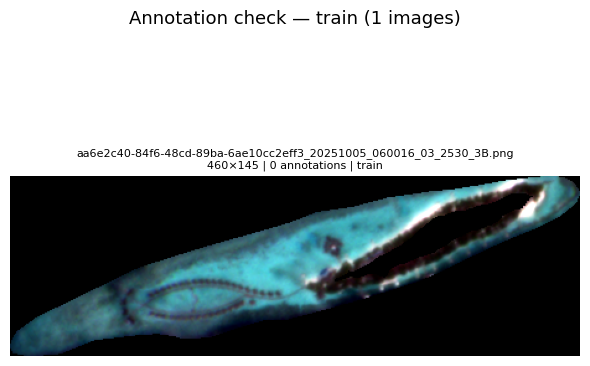

In [4]:
import shutil
import albumentations as A
import numpy as np

all_destination = WORK_ROOT / 'islands-3cm-base'
assert not all_destination.exists()
if all_destination.exists():
    shutil.rmtree(all_destination)

#
'''all_plan = dataset.rename_classes(
    {0: "school"}
).remove_classes({1,2}).split(
    ratios={'train': 0.75, 'val': 0.25}, 
    seed=1337,
    group_by=get_aoi,
)'''

all_plan = dataset.rename_classes(
    {0: "school"}
).remove_classes({1,2}, merge_into=0).split(
    ratios={'train': 0.75, 'val': 0.25}, 
    seed=1337,
    group_by=get_aoi,
)

print(all_plan)

result = all_plan.export(destination=all_destination)
print(result)

In [5]:
%matplotlib inline

from dataset_fixer import Dataset
from dataset_fixer import Task
#dataset = Dataset.open("/Users/tristan/Downloads/Merged_Annotations", task=Task.SEGMENT, errors='skip')
#dataset = Dataset.open("/Users/tristan/Downloads/island-dataset/20260804-all-annotations", task=Task.SEGMENT, errors='skip')
#dataset = Dataset.open("/Users/tristan/Downloads/island-dataset/islands-fair-base", task=Task.SEGMENT, errors='skip')
dataset = Dataset.open("/Users/tristan/Downloads/island-dataset/islands-3cm-base", task=Task.SEGMENT, errors='skip')
print(dataset)

Loading YOLO dataset:   0%|          | 0/4692 [00:00<?, ?image/s]

Validating dataset:   0%|          | 0/4692 [00:00<?, ?image/s]

Dataset '20260805-merged-annotations-3class__rename-school__95f012b5__merge-Fish_2-Fish_3-into-school__6f5a6bdd__split-train75-val25__48f749b1' [segment; materialized; yolo]
  images: 4692 | annotations: 1037 | empty: 4234 (90.2%)
  classes: 1 | splits: 2
  image sizes: 177 unique | width 69-4733 | height 65-2841
  location: /Users/tristan/Downloads/island-dataset/islands-3cm-base

  Split statistics
    split  images  annotated  empty  annotations
    -----  ------  ---------  -----  -----------
    train    3484        343   3141          744
    val      1208        115   1093          293
    total    4692        458   4234         1037

  Class statistics (annotation instances and images containing class)
    id  name    annotations  images  image %
    --  ------  -----------  ------  -------
     0  school         1037     458     9.8%
  data_yaml: /Users/tristan/Downloads/island-dataset/islands-3cm-base/data.yaml
  validation: passed_with_skips | warnings: 0 | skipped: 1 (see v

In [2]:
#dataset.export(destination="/Users/tristan/Downloads/island-dataset/islands-fair-base-sem", format="semantic_masks")

In [6]:
import shutil
import albumentations as A
import numpy as np
from datetime import datetime

current_date = datetime.now().strftime("%d.%m.%Y")
tile_size = 128
#tile_size = 512
all_destination = WORK_ROOT / f'islands-{tile_size}-{current_date}-merged-3class'
assert not all_destination.exists()
if all_destination.exists():
    shutil.rmtree(all_destination)

camera_pipeline = A.Compose([
    # Applied to the complete source image before selecting each crop.
    A.Affine(
        p=1.0,
        scale=(1.0, 1.35),
        rotate=(-160, 160),
        translate_percent=(-0.05, 0.05),
        fill=0,

    ),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.3),
    A.RandomGamma(p=0.3),

])

val_camera_pipeline = A.Compose([
    # Applied to the complete source image before selecting each crop.
    A.Affine(
        p=1.0,
        scale=(1.0, 1.05),
        rotate=(-160, 160),
        translate_percent=(-0.05, 0.05),
        fill=0,

    ),
    #A.RandomBrightnessContrast(p=0.3),
    #A.HueSaturationValue(p=0.3),
    #A.RandomGamma(p=0.3),

])

#
#all_plan = dataset#.remove_classes(
    #{1,2}
#).remove_classes(
#    {1}, merge_into=0
all_plan = dataset.tile(
    mode='coverage',
    tile_size=tile_size,
    min_area_ratio=0.50,
    negative_tiles='all',
    visualize=True,
    target_appearances_per_object=5,
    sparse_appearances_per_object=5,
    
    background_ratio=0.35,
    max_background_tiles_per_source_image=1,
    background_filter=lambda tile: np.asarray(tile).sum() > 0,  # filter out all-black tiles

    crop_transforms=camera_pipeline,
    val_crop_transforms=val_camera_pipeline,
    augment_val=True,

    allow_lossy=False,
    errors="skip"
)

print(all_plan)


Dataset '20260805-merged-annotations-3class__rename-school__95f012b5__merge-Fish_2-Fish_3-into-school__6f5a6bdd__split-train75-val25__48f749b1__tile-coverage-128__72aab939' [segment; virtual pipeline; yolo]
  images: pending export | annotations: pending export | empty: pending export
  classes: 1 | splits: 2
  location: /Users/tristan/Downloads/island-dataset/islands-3cm-base
  class names: 0:school
  pending: tile
  export required: data_yaml and training_ready are unavailable until export()
  validation: passed_with_skips | warnings: 0 | skipped: 1 (see validation_audit)


Dataset '20260805-merged-annotations-3class__rename-school__95f012b5__merge-Fish_2-Fish_3-into-school__6f5a6bdd__split-train75-val25__48f749b1__tile-coverage-128__72aab939' [segment; virtual pipeline; yolo]
  images: pending export | annotations: pending export | empty: pending export
  classes: 1 | splits: 2
  location: /Users/tristan/Downloads/island-dataset/islands-3cm-base
  class names: 0:school
  pending: tile
  export required: data_yaml and training_ready are unavailable until export()
  validation: passed_with_skips | warnings: 0 | skipped: 1 (see validation_audit)

Export destination: /Users/tristan/Downloads/island-dataset/islands-128-08.08.2026-merged-3class_yolo

Materializing pipeline step 1/1: tile

tile-coverage: step-001-tile
Destination: /Users/tristan/Downloads/island-dataset/.islands-128-08.08.2026-merged-3class_yolo.pipeline-jnd7fo4n/step-001-tile
Images: 4692 | splits: ['train', 'val']
Settings: {"allow_lossy": false, "augment_val": true, "background_filter": {"mo

Coverage tiling:   0%|          | 0/4692 [00:00<?, ?image/s]


Created step-001-tile
Location: /Users/tristan/Downloads/island-dataset/.islands-128-08.08.2026-merged-3class_yolo.pipeline-jnd7fo4n/step-001-tile
data.yaml: /Users/tristan/Downloads/island-dataset/.islands-128-08.08.2026-merged-3class_yolo.pipeline-jnd7fo4n/step-001-tile/data.yaml
Settings fingerprint: e7de2366
Duration: 572.30s | throughput: 7.84 images/s | images: 4484 | annotations: 4327 | training_ready: True
Warnings: 183 (see reports/dataset-info.json)
Visual audits: ['reports/plots.png']
Reports: /Users/tristan/Downloads/island-dataset/.islands-128-08.08.2026-merged-3class_yolo.pipeline-jnd7fo4n/step-001-tile/reports
Split-group audit: passed (all current source splits)
  train: 3149 images / 103 groups | group size min=1, median=18, mean=30.5728, max=385
  val: 1335 images / 33 groups | group size min=1, median=24, mean=40.4545, max=484
Export sanity preview: /Users/tristan/Downloads/island-dataset/.islands-128-08.08.2026-merged-3class_yolo.tmp-ap3hh6er/reports/export_preview

Exporting YOLO dataset:   0%|          | 0/4484 [00:00<?, ?image/s]

Validating complete staged output before atomic publication (streaming, bounded memory)...


...

Reusing validated in-memory index; published dataset is not rescanned.

Created 20260805-merged-annotations-3class__rename-school__95f012b5__merge-Fish_2-Fish_3-into-school__6f5a6bdd__split-train75-val25__48f749b1__tile-coverage-128__72aab939
Location: /Users/tristan/Downloads/island-dataset/islands-128-08.08.2026-merged-3class_yolo
data.yaml: /Users/tristan/Downloads/island-dataset/islands-128-08.08.2026-merged-3class_yolo/data.yaml
Settings fingerprint: 93f32cc9
Duration: 173.26s | throughput: 25.88 images/s | images: 4484 | annotations: 4327 | training_ready: True
Warnings: 183 (see reports/dataset-info.json)
Visual audits: ['reports/plots.png']
Reports: /Users/tristan/Downloads/island-dataset/islands-128-08.08.2026-merged-3class_yolo/reports
Split-group audit: passed (all current source splits)
  train: 3149 images / 103 groups | group size min=1, median=18, mean=30.5728, max=385
  val: 1335 images / 33 groups | group size min=1, median=24, mean=40.4545, max=484

semantic-mask expo

Exporting semantic masks:   0%|          | 0/4484 [00:00<?, ?image/s]

Loading semantic-mask dataset:   0%|          | 0/4484 [00:00<?, ?pair/s]

Validating dataset:   0%|          | 0/4484 [00:00<?, ?image/s]


Created 20260805-merged-annotations-3class__rename-school__95f012b5__merge-Fish_2-Fish_3-into-school__6f5a6bdd__split-train75-val25__48f749b1__tile-coverage-128__72aab939__semantic-masks__bc1f78a1
Location: /Users/tristan/Downloads/island-dataset/islands-128-08.08.2026-merged-3class_masks
Images/masks: 4484/4484


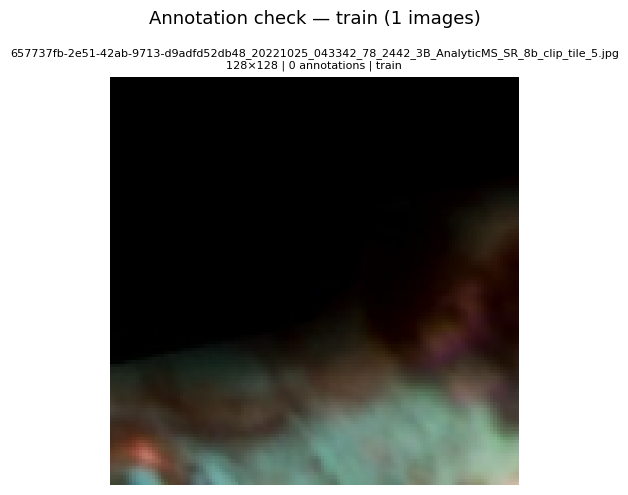

In [7]:
result = all_plan.export_formats({
    "yolo": Path(f"{all_destination}_yolo"),
    "semantic_masks": Path(f"{all_destination}_masks"),
})

## 4. Tile with negative crops removed

The crop geometry is unchanged; only empty output tiles are excluded. Comparing provenance counts makes the policy effect explicit.

In [ ]:
positive_destination = WORK_ROOT / 'sawit-grid-positive-only'
if positive_destination.exists():
    shutil.rmtree(positive_destination)

positive_plan = dataset.tile(
    mode='grid', tile_size=640, overlap=0.20, min_area_ratio=0.10,
    negative_tiles='none', visualize=True,
)
positive_tiles = positive_plan.export(destination=positive_destination)
print('all tiles:', len(all_tiles.provenance))
print('positive-only tiles:', len(positive_tiles.provenance))
assert len(positive_tiles.provenance) <= len(all_tiles.provenance)

## 5. Inspect exact source mapping

Every output tile records its immediate parent, ultimate original, crop coordinates, scale, tile index, annotation count, and transformation chain.

In [ ]:
import json
record = next(iter(all_tiles.provenance.values()))
print(json.dumps(record, indent=2)[:2000])
print('effective settings:', all_tiles.settings)
print('training ready:', all_tiles.training_ready)

### Geometry rules for other tasks

- **Segmentation:** polygons are intersected geometrically with each crop.
- **Pose:** outside keypoints become `(0, 0, 0)` and insufficient instances are removed.
- **POLO grid:** points remain only when their complete configured radius circle fits.
- **POLO coverage mode:** randomized crops target per-point coverage and resize to the requested output resolution.